# 1. Data import and investigation

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# exploration and cleaning of original data
df_orig = pd.read_csv(r"original_data_2.csv", delimiter=';')
#df = df_orig
# taking a look at basic info about dataframe
display(df_orig.columns)
display(df_orig.dtypes)
df_orig.sample(5)

Index(['year', 'country', 'Name of a bank', 'TOT_COMP_AW_TO_CEO__EQUIV',
       'TOT_COMPENSATION_AW_TO_EXECS', 'TOT_SALARIES_PAID_TO_CEO__EQUIV',
       'TOT_SAL__BNS_AW_TO_CEO__EQUIV', 'TOT_SALARIES__BNS_PD_TO_EXECS',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'],
      dtype='object')

year                                 int64
country                             object
Name of a bank                      object
TOT_COMP_AW_TO_CEO__EQUIV          float64
TOT_COMPENSATION_AW_TO_EXECS       float64
TOT_SALARIES_PAID_TO_CEO__EQUIV    float64
TOT_SAL__BNS_AW_TO_CEO__EQUIV      float64
TOT_SALARIES__BNS_PD_TO_EXECS      float64
Unnamed: 8                         float64
Unnamed: 9                         float64
Unnamed: 10                         object
dtype: object

,year,country,Name of a bank,TOT_COMP_AW_TO_CEO__EQUIV,TOT_COMPENSATION_AW_TO_EXECS,TOT_SALARIES_PAID_TO_CEO__EQUIV,TOT_SAL__BNS_AW_TO_CEO__EQUIV,TOT_SALARIES__BNS_PD_TO_EXECS,Unnamed: 8,Unnamed: 9,Unnamed: 10
2001,2014,USA,CNB Corporation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2058,2011,USA,"Carroll Bancorp, Inc.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306,2011,Denmark,Kreditbanken A/S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2534,2013,USA,First Financial Corporation,1443508.0,3031300.0,626097.0,908114.0,2008037.0,505216.67,334672.83,0
3031,2014,USA,Pacific Alliance Bank,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Description of the columns </br>
TOT_COMP_AW_TO_CEO__EQUIV "Total compensation paid to CEO or equivalent" </br>
TOT_COMPENSATION_AW_TO_EXECS "Total compensation paid to executives" </br>
TOT_SALARIES_PAID_TO_CEO__EQUIV " Total salaries paid to CEO or equivalent " </br>
TOT_SAL__BNS_AW_TO_CEO__EQUIV " Total salaries and bonus amount paid to CEO or equivalent " </br>
TOT_SALARIES__BNS_PD_TO_EXECS " Total salaries and bonus amount paid to executives" </br>


In the dataframe there are also 3 unnamed columns. Some banks have them filled but we do not know what exactly this data is as there is no mention on it in the description sheet of the original excel file. </br> </br>

The unnamed column will be deleted. When it comes to N/A values which there is plenty of they will be dropped. The fact that it's missing doesnt provide any value and reasons to question why it is missing. Although count of available data for banks should be visualized and mentioned constantly if some countries would be found to have very scarce records.


In [24]:
# dropping unidentified columns
df = df_orig.drop(columns=['Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'])

df['country'].astype('str')
# dropping na's
df.dropna(inplace=True)
df.head()
df.dtypes

year                                 int64
country                             object
Name of a bank                      object
TOT_COMP_AW_TO_CEO__EQUIV          float64
TOT_COMPENSATION_AW_TO_EXECS       float64
TOT_SALARIES_PAID_TO_CEO__EQUIV    float64
TOT_SAL__BNS_AW_TO_CEO__EQUIV      float64
TOT_SALARIES__BNS_PD_TO_EXECS      float64
dtype: object

# 2. Analysis

### 1. Number of banks per country. </br> 
The first look already tells us that we wont be able to get a clear comparison of executive's remuneration in respect to other countries. United states have outstandingly more data than other countries which has to be kept in mind when interpreting further results. <br>
We will quickly create new column for later analysis. It will contain information about continent, since we have only european countries and USA it won't be to complicated. <br>
As it can be seen there is stil a noticable difference in the size of groups but it's much more comparable than comparing by country

,country,Name of a bank
0,Austria,3
1,Belgium,2
2,Denmark,3
3,France,6
4,Germany,4
5,Greece,1
6,Iceland,1
7,Ireland,2
8,Netherlands,1
9,Spain,7


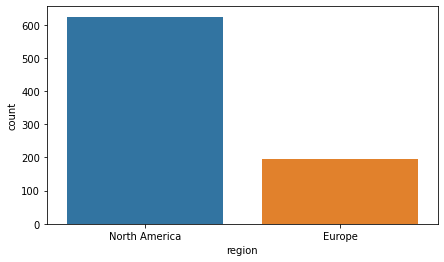

<Figure size 432x288 with 0 Axes>

In [25]:
display(df.groupby('country', as_index=False)['Name of a bank'].nunique())

region = []
for row in df['country']:
    if row=='USA':
        region.append('North America')
    else:
        region.append('Europe')

df['region'] = region

fig, ax1 = plt.subplots()
fig.set_size_inches([7,4])
sns.countplot(data=df, x='region', ax=ax1, order = df['region'].value_counts().index)
plt.show()
plt.clf()

After looking at amount of observations per year it is also visible that many are too low to be able to provide valueable information. Years that have less than 100 observations will be dropped.

2008      8
2009    116
2010    121
2011    136
2012    138
2013    140
2014    139
2015     13
2016      2
2017      3
2018      2
Name: year, dtype: int64


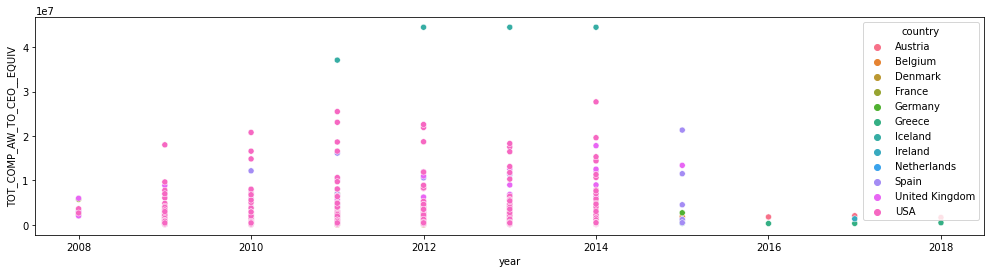

<Figure size 432x288 with 0 Axes>

In [26]:
print(df['year'].value_counts().sort_index())

fig, ax1 = plt.subplots()
sns.scatterplot(x='year', y='TOT_COMP_AW_TO_CEO__EQUIV', data=df, hue='country', ax=ax1)
fig.set_size_inches([17,4])
plt.show()
plt.clf()

In [27]:
# quick check, before we plotted only one column maybe it had n/a's etc.
print(df.isnull().values.any())
years_count = dict(df['year'].value_counts().sort_index())
years_keep = [key for key, value in years_count.items() if value>100]

dfa = df[df['year'].isin(years_keep)]
dfa = dfa.reset_index(drop=True)

False


### 2. Outliers

Large amount of outliers is visible below and in the describe section. The group consists of large multinational banks as well as small regional ones. In this instance the best course of action would be logarythmising the conpensations values which will reduce spread and possibly enable to use modelling tools. Dropping this amount of outliers in alredy small group would not be the best course of action.

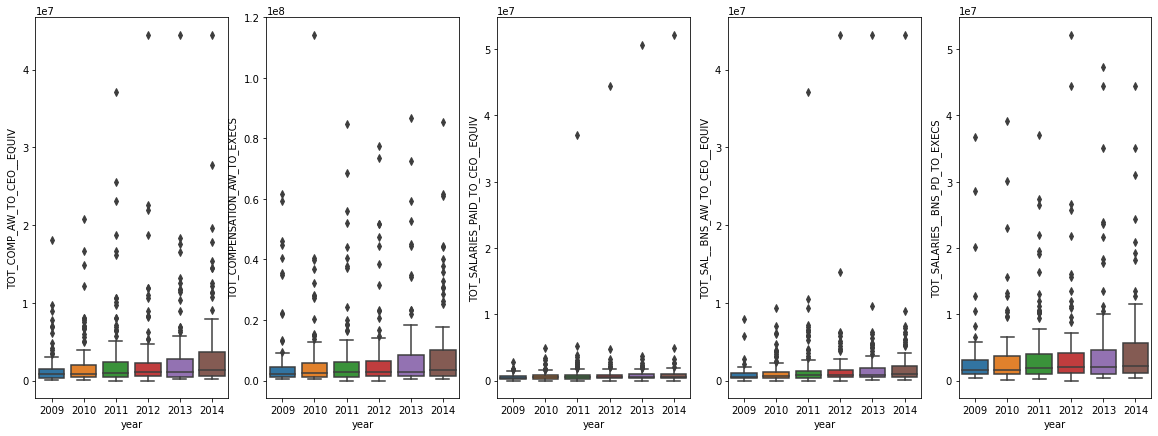

,TOT_COMP_AW_TO_CEO__EQUIV,TOT_COMPENSATION_AW_TO_EXECS,TOT_SALARIES_PAID_TO_CEO__EQUIV,TOT_SAL__BNS_AW_TO_CEO__EQUIV,TOT_SALARIES__BNS_PD_TO_EXECS
count,790.00,790.00,790.00,790.00,790.00
mean,2547052.60,7101962.55,945487.04,1407945.45,3925031.63
std,4639715.38,12580134.81,3318352.14,3321687.37,6148036.23
min,0.86,1.92,0.00,0.00,1.64
25%,474113.00,1305224.00,305100.00,350032.50,1025226.50
50%,999455.50,2738028.50,500000.50,692775.53,1940162.00
75%,2448592.50,6852719.50,868939.95,1372916.75,4110733.25
max,44500000.00,114300000.00,52200000.00,44500000.00,52212123.00


<Figure size 432x288 with 0 Axes>

In [77]:
fig, (ax0, ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=5)
sns.boxplot(x='year', y='TOT_COMP_AW_TO_CEO__EQUIV', data=dfa, ax=ax0)
sns.boxplot(x='year', y='TOT_COMPENSATION_AW_TO_EXECS', data=dfa, ax=ax1)
sns.boxplot(x='year', y='TOT_SALARIES_PAID_TO_CEO__EQUIV', data=dfa, ax=ax2)
sns.boxplot(x='year', y='TOT_SAL__BNS_AW_TO_CEO__EQUIV', data=dfa, ax=ax3)
sns.boxplot(x='year', y='TOT_SALARIES__BNS_PD_TO_EXECS', data=dfa, ax=ax4)
fig.set_size_inches(20,7)
plt.show()
plt.clf()

display(dfa.iloc[:,3:8].describe().applymap(lambda x: '%.2f'%x))

In [81]:
# ln for all remun cols ............
dfa.shape

(790, 9)

### 3. Analysis of remuneration

* #### On whole population

....................

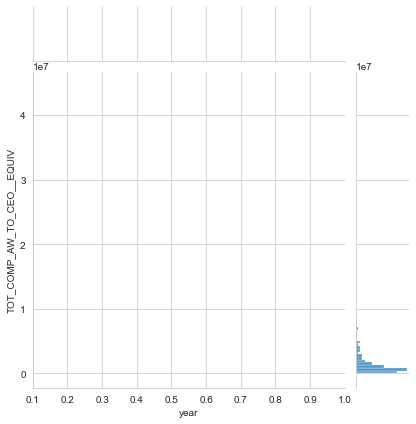

<Figure size 432x288 with 0 Axes>

In [24]:
sns.set_style("whitegrid")
g = sns.JointGrid(x = 'year', y = 'TOT_COMP_AW_TO_CEO__EQUIV', data=dfa, xlim = (0.1, 1.0))
g.plot(sns.lineplot, sns.histplot)
plt.show()
plt.clf()

* #### Per region

In [20]:
# plots etc...

### 3. ....